# ValoraCasa Sección 12: Modelo Predictivo

**Equipo:** The FI-ndings
Facultad de Ingeniería, UNAM
---

Este notebook construye tres modelos de regresión supervisada para estimar la renta mensual de una vivienda en México, usando datos oficiales de la ENIGH 2024 del INEGI.

**Variable objetivo:** `renta`  valor mensual estimado en pesos mexicanos

**Modelos a comparar:**
- Regresión Lineal (baseline)
- Random Forest
- XGBoost (Gradient Boosting)

In [ ]:
# ── Instalación de librerías necesarias ──────────────────────────────────────
# XGBoost ya viene en Colab, pero lo instalamos por si acaso
!pip install xgboost --quiet

# ── Importaciones ─────────────────────────────────────────────────────────────
import pandas as pd          # Manejo de tablas de datos
import numpy as np           # Operaciones matemáticas
import matplotlib.pyplot as plt   # Gráficas
import seaborn as sns             # Gráficas estadísticas

# Preprocesamiento
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# División del dataset
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# Modelos
from sklearn.linear_model import LinearRegression #MODELO DE REGRESION LINEA
from sklearn.ensemble import RandomForestRegressor #MODELOS DE RANDOM FOREST
from xgboost import XGBRegressor #MODELO DE XGBOOST

# Métricas
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


In [ ]:
# ── Cargar el dataset ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

ruta = '/content/drive/MyDrive/PROYECTO CD /viviendas_limpio_valuacasa.csv'
df_raw = pd.read_csv(ruta)

print(f'Dataset cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
df_raw.head(3)

Dataset cargado: 90,324 filas × 50 columnas


,folioviv,tenencia,renta,ubica_geo,tam_loc,est_socio,tipo_viv,mat_pared,mat_techos,mat_pisos,...,aire_acond,calefacc,p_grietas,p_pandeos,p_levanta,p_humedad,p_fractura,p_electric,p_tuberias,antiguedad_no_especificada
0,100001901,1,1500,1001,1,3,7,8,10,3,...,2,2,2,2,2,2,2,2,2,0
1,100001902,3,0,1001,1,3,1,8,10,3,...,2,2,2,2,2,2,2,2,2,0
2,100001904,1,1000,1001,1,3,1,8,10,3,...,2,2,2,2,2,2,2,2,2,1


## Filtrado y preparación de la variable objetivo

Solo 11,566 de los 90,324 registros tienen renta mayor a cero.
El resto son viviendas propias, prestadas o heredadas

NOTA IMPORTANTE: La renta no aplica

Pasos:
1. Filtrar registros con renta > 0
2. Eliminar outliers (rentas sobre el percentil 99)
3. Aplicar transformación logarítmica log(renta + 1)

Registros con renta > 0: 11,566
Percentil 99: $16,000
Registros tras quitar outliers: 11,455

Renta original  → media: $3,028 | mediana: $2,500
log(renta+1)    → media: 7.7849 | mediana: 7.8244


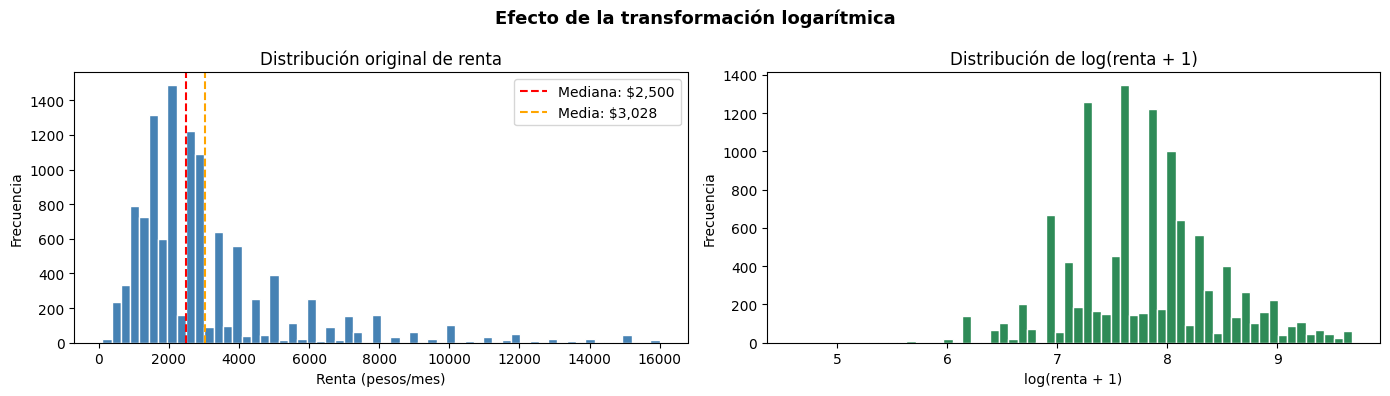

In [ ]:
# ── Paso 1: Filtrar viviendas con renta registrada ────────────────────────────
df = df_raw[df_raw['renta'] > 0].copy()
print(f'Registros con renta > 0: {len(df):,}')

# ── Paso 2: Eliminar outliers extremos (sobre el percentil 99) ────────────────
# Rentas exageradamente altas distorsionan el aprendizaje del modelo
p99 = df['renta'].quantile(0.99)
df = df[df['renta'] <= p99].copy()
print(f'Percentil 99: ${p99:,.0f}')
print(f'Registros tras quitar outliers: {len(df):,}')

# ── Paso 3: Transformación logarítmica ────────────────────────────────────────
# La distribución de renta es asimétrica (cola larga a la derecha).
# log1p comprime los valores extremos y equilibra la distribución.
# log1p(x) = log(x + 1) — el +1 evita problemas si hubiera algún cero.
df['log_renta'] = np.log1p(df['renta'])

print(f'\nRenta original  → media: ${df["renta"].mean():,.0f} | mediana: ${df["renta"].median():,.0f}')
print(f'log(renta+1)    → media: {df["log_renta"].mean():.4f} | mediana: {df["log_renta"].median():.4f}')

# ── Visualización: comparar distribución antes y después del logaritmo ────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['renta'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(df['renta'].median(), color='red', linestyle='--', label=f'Mediana: ${df["renta"].median():,.0f}')
axes[0].axvline(df['renta'].mean(), color='orange', linestyle='--', label=f'Media: ${df["renta"].mean():,.0f}')
axes[0].set_title('Distribución original de renta')
axes[0].set_xlabel('Renta (pesos/mes)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

axes[1].hist(df['log_renta'], bins=60, color='seagreen', edgecolor='white')
axes[1].set_title('Distribución de log(renta + 1)')
axes[1].set_xlabel('log(renta + 1)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Efecto de la transformación logarítmica', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Corrección de variables con codificación 1/2

En la ENIGH, muchas variables binarias usan la escala:
- 1 = Sí tiene
- 2 = No tiene

Eso es contraintuitivo para el modelo. Lo convertimos a:
- 1 = Sí tiene
- 0 = No tiene

También corregimos las variables de problemas estructurales
donde el valor 9 significa "No especificado", el cual lo tratamos como 0 (sin problema reportado).

In [ ]:
# ── Variables con codificación Sí=1, No=2 || convertir a Sí=1, No=0 ──────────
vars_1_2 = [
    'cocina', 'lavadero', 'fregadero', 'regadera', 'tinaco_azo',
    'cisterna', 'pileta', 'calent_sol', 'calent_gas', 'medid_luz',
    'bomba_agua', 'tanque_gas', 'aire_acond', 'calefacc'
]

for var in vars_1_2:
    if var in df.columns:
        df[var] = df[var].map({1: 1, 2: 0})

print('Variables 1/2 convertidas a 1/0')

# ── Variables de problemas estructurales ──────────────────────────────────────
# 1 = Sí tiene el problema, 2 = No tiene, 9 = No especificado
# Convertimos: 1 a 1 (sí hay problema), 2 a 0 (no hay problema), 9 a 0 (sin info = sin problema)
vars_problemas = [
    'p_grietas', 'p_pandeos', 'p_levanta', 'p_humedad',
    'p_fractura', 'p_electric', 'p_tuberias'
]

for var in vars_problemas:
    if var in df.columns:
        df[var] = df[var].map({1: 1, 2: 0, 9: 0})

print('Variables de problemas estructurales corregidas (9 → 0)')

# ── Verificación ──────────────────────────────────────────────────────────────
print('\nVerificación — valores únicos tras corrección:')
for var in vars_1_2 + vars_problemas:
    if var in df.columns:
        print(f'   {var}: {sorted(df[var].dropna().unique())}')

Variables 1/2 convertidas a 1/0
Variables de problemas estructurales corregidas (9 → 0)

Verificación — valores únicos tras corrección:
   cocina: [np.int64(0), np.int64(1)]
   lavadero: [np.int64(0), np.int64(1)]
   fregadero: [np.int64(0), np.int64(1)]
   regadera: [np.int64(0), np.int64(1)]
   tinaco_azo: [np.int64(0), np.int64(1)]
   cisterna: [np.int64(0), np.int64(1)]
   pileta: [np.int64(0), np.int64(1)]
   calent_sol: [np.int64(0), np.int64(1)]
   calent_gas: [np.int64(0), np.int64(1)]
   medid_luz: [np.int64(0), np.int64(1)]
   bomba_agua: [np.int64(0), np.int64(1)]
   tanque_gas: [np.int64(0), np.int64(1)]
   aire_acond: [np.int64(0), np.int64(1)]
   calefacc: [np.int64(0), np.int64(1)]
   p_grietas: [np.int64(0), np.int64(1)]
   p_pandeos: [np.int64(0), np.int64(1)]
   p_levanta: [np.int64(0), np.int64(1)]
   p_humedad: [np.int64(0), np.int64(1)]
   p_fractura: [np.int64(0), np.int64(1)]
   p_electric: [np.int64(0), np.int64(1)]
   p_tuberias: [np.int64(0), np.int64(1)]


## Variable geográfica: renta promedio por municipio

ubica_geo contiene la clave de municipio (763 valores únicos).
En lugar de usarla como categoría, calculamos la renta promedio
de cada municipio y la usamos como variable numérica continua.

Esto le da al modelo información geográfica real y significativa.

In [ ]:
# ── Renta promedio por municipio ──────────────────────────────────────────────
# Calculamos la renta promedio de cada municipio usando nuestros datos
renta_por_municipio = df.groupby('ubica_geo')['renta'].mean()

# Creamos la nueva variable numérica
df['renta_media_municipio'] = df['ubica_geo'].map(renta_por_municipio)

print('Variable geográfica creada: renta_media_municipio')
print(f'   Municipios únicos: {df["ubica_geo"].nunique()}')
print(f'   Renta media municipio → min: ${df["renta_media_municipio"].min():,.0f} | max: ${df["renta_media_municipio"].max():,.0f}')

print('\nTop 5 municipios con mayor renta promedio:')
print(renta_por_municipio.sort_values(ascending=False).head().apply(lambda x: f'${x:,.0f}'))

print('\nTop 5 municipios con menor renta promedio:')
print(renta_por_municipio.sort_values(ascending=True).head().apply(lambda x: f'${x:,.0f}'))

Variable geográfica creada: renta_media_municipio
   Municipios únicos: 763
   Renta media municipio → min: $200 | max: $15,000

Top 5 municipios con mayor renta promedio:
ubica_geo
11003    $15,000
21106    $11,000
15076    $10,000
9014      $9,782
9016      $9,222
Name: renta, dtype: object

Top 5 municipios con menor renta promedio:
ubica_geo
22010    $200
13049    $300
20197    $400
20002    $400
30092    $400
Name: renta, dtype: object


## Definición de variables y división entrenamiento/prueba

Se definen los tres grupos de variables predictoras según su naturaleza,
y se divide el dataset en 80% entrenamiento y 20% prueba.

La división es estratificada por est_socio para garantizar que
todos los estratos socioeconómicos estén representados en ambas partes.

In [ ]:
# ── Definición de grupos de variables ─────────────────────────────────────────

# Ordinales: tienen un orden lógico natural
vars_ordinales = [
    'tam_loc',      # Tamaño de localidad
    'est_socio',    # Estrato socioeconómico (1=bajo y 4=alto)
    'dotac_agua',   # Días con dotación de agua
    'focos',        # Número de focos
    'num_cuarto',   # Número de cuartos totales
    'cuart_dorm',   # Cuartos para dormir
    'antiguedad',   # Antigüedad de la vivienda
    'bano_comp',    # Número de baños completos
    'bano_excus',   # Número de baños con excusado
    'bano_regad',   # Número de baños con regadera
]

# Nominales: categorías sin orden → requieren One-Hot Encoding
vars_nominales = [
    'tipo_viv', 'mat_pared', 'mat_techos', 'mat_pisos',
    'lugar_coc', 'agua_ent', 'ab_agua', 'sanit_agua',
    'excusado', 'uso_compar', 'drenaje', 'disp_elect',
    'combus', 'eli_basura'
]

# Binarias: ya son 0/1, pasan sin transformación
vars_binarias = [
    'cocina', 'lavadero', 'fregadero', 'regadera', 'tinaco_azo',
    'cisterna', 'pileta', 'calent_sol', 'calent_gas', 'medid_luz',
    'bomba_agua', 'tanque_gas', 'aire_acond', 'calefacc',
    'p_grietas', 'p_pandeos', 'p_levanta', 'p_humedad',
    'p_fractura', 'p_electric', 'p_tuberias',
    'antiguedad_no_especificada'
]

# Geográfica: numérica continua
vars_geograficas = ['renta_media_municipio']

# ── Todas las variables predictoras juntas ────────────────────────────────────
FEATURES = vars_ordinales + vars_nominales + vars_binarias + vars_geograficas
TARGET = 'log_renta'

print(f'Variables predictoras: {len(FEATURES)} en total')
print(f'   Ordinales:  {len(vars_ordinales)}')
print(f'   Nominales:  {len(vars_nominales)}')
print(f'   Binarias:   {len(vars_binarias)}')
print(f'   Geográfica: {len(vars_geograficas)}')
print(f'\n Variable objetivo: {TARGET}')

# ── División 80% entrenamiento / 20% prueba ───────────────────────────────────
X = df[FEATURES].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=df['est_socio']   # Estratificado por estrato socioeconómico
)

print(f'\nDivisión completada:')
print(f'   Entrenamiento: {X_train.shape[0]:,} registros (80%)')
print(f'   Prueba:        {X_test.shape[0]:,} registros (20%)')

# Verificar estratificación
print('\nDistribución de estratos (debe ser igual en train y test):')
train_dist = X_train['est_socio'].value_counts(normalize=True).sort_index().round(3)
test_dist  = X_test['est_socio'].value_counts(normalize=True).sort_index().round(3)
resumen = pd.DataFrame({'Entrenamiento': train_dist, 'Prueba': test_dist})
print(resumen)

Variables predictoras: 47 en total
   Ordinales:  10
   Nominales:  14
   Binarias:   22
   Geográfica: 1

 Variable objetivo: log_renta

División completada:
   Entrenamiento: 9,164 registros (80%)
   Prueba:        2,291 registros (20%)

Distribución de estratos (debe ser igual en train y test):
           Entrenamiento  Prueba
est_socio                       
1                  0.091   0.091
2                  0.479   0.479
3                  0.291   0.290
4                  0.140   0.140


## Modelo 1: Regresión Lineal (baseline)

Establece una relación lineal entre las variables predictoras y la renta.
Es el modelo más simple del pipeline y funciona como punto de referencia:
cualquier modelo más complejo debe superarlo para justificar su uso.


In [ ]:
# ── Preprocesador ─────────────────────────────────────────────────────────────
# ColumnTransformer aplica transformaciones distintas según el tipo de variable
preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal',
         OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         vars_ordinales),

        ('onehot',
         OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         vars_nominales),

        ('passthrough',
         'passthrough',
         vars_binarias + vars_geograficas),
    ],
    remainder='drop'
)

# ── Pipeline: preprocesar + entrenar ──────────────────────────────────────────
pipe_lineal = Pipeline([
    ('prep',    preprocessor),
    ('modelo',  LinearRegression())
])

pipe_lineal.fit(X_train, y_train)

# ── Evaluación rápida en train y test ─────────────────────────────────────────
y_pred_train = pipe_lineal.predict(X_train)
y_pred_test  = pipe_lineal.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test,  y_pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))

print('REGRESIÓN LINEAL (baseline)')
print(f'   R²   → Train: {r2_train:.4f} | Test: {r2_test:.4f}')
print(f'   RMSE → Train: {rmse_train:.4f} | Test: {rmse_test:.4f}')
print('\nModelo 1 entrenado')

REGRESIÓN LINEAL (baseline)
   R²   → Train: 0.6241 | Test: 0.6163
   RMSE → Train: 0.4102 | Test: 0.4075

Modelo 1 entrenado


## Modelo 2: Random Forest

Construye 200 árboles distintos y promedia sus predicciones.
Más robusto que la regresión lineal y capaz de capturar
relaciones no lineales entre las variables y la renta.

In [ ]:
pipe_rf = Pipeline([
    ('prep',   preprocessor),
    ('modelo', RandomForestRegressor(
        n_estimators=200,    # 200 árboles
        max_depth=20,        # Profundidad máxima de cada árbol
        min_samples_leaf=5,  # Mínimo 5 registros por hoja
        random_state=SEED,
        n_jobs=-1            # Usar todos los núcleos disponibles
    ))
])

print('Entrenando Random Forest...')
pipe_rf.fit(X_train, y_train)

# ── Evaluación ────────────────────────────────────────────────────────────────
y_pred_train = pipe_rf.predict(X_train)
y_pred_test  = pipe_rf.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test,  y_pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))

print('\nRANDOM FOREST')
print(f'   R²   → Train: {r2_train:.4f} | Test: {r2_test:.4f}')
print(f'   RMSE → Train: {rmse_train:.4f} | Test: {rmse_test:.4f}')
print('\nModelo 2 entrenado')

Entrenando Random Forest...

RANDOM FOREST
   R²   → Train: 0.8203 | Test: 0.6569
   RMSE → Train: 0.2837 | Test: 0.3854

Modelo 2 entrenado


## Modelo 3: XGBoost (Gradient Boosting)

Construye árboles en secuencia: cada árbol corrige los errores del anterior.
Generalmente el más preciso para datos tabulares como la ENIGH.

In [ ]:
pipe_xgb = Pipeline([
    ('prep',   preprocessor),
    ('modelo', XGBRegressor(
        n_estimators=300,      # 300 árboles en secuencia
        learning_rate=0.05,    # Qué tan rápido aprende cada árbol
        max_depth=6,           # Árboles menos profundos que RF
        subsample=0.8,         # Usa el 80% de datos por árbol
        colsample_bytree=0.8,  # Usa el 80% de variables por árbol
        random_state=SEED,
        n_jobs=-1,
        verbosity=0
    ))
])

print('Entrenando XGBoost...')
pipe_xgb.fit(X_train, y_train)

# ── Evaluación ────────────────────────────────────────────────────────────────
y_pred_train = pipe_xgb.predict(X_train)
y_pred_test  = pipe_xgb.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test,  y_pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))

print('\nXGBOOST')
print(f'   R²   → Train: {r2_train:.4f} | Test: {r2_test:.4f}')
print(f'   RMSE → Train: {rmse_train:.4f} | Test: {rmse_test:.4f}')
print('\n Modelo 3 entrenado')

Entrenando XGBoost...

XGBOOST
   R²   → Train: 0.8074 | Test: 0.6753
   RMSE → Train: 0.2937 | Test: 0.3749

 Modelo 3 entrenado


## Validación cruzada (5 pliegues)

Divide el entrenamiento en 5 grupos. El modelo se entrena y evalúa
5 veces, usando cada vez un grupo diferente como prueba interna.

Esto da una estimación más confiable del desempeño real,
porque no depende de una sola división de los datos.

In [ ]:
print('Ejecutando validación cruzada...\n')

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

# ── Validación cruzada de los 3 modelos ───────────────────────────────────────
cv_lineal = cross_val_score(pipe_lineal, X_train, y_train,
                            cv=kf, scoring='r2', n_jobs=-1)

cv_rf     = cross_val_score(pipe_rf, X_train, y_train,
                            cv=kf, scoring='r2', n_jobs=-1)

cv_xgb    = cross_val_score(pipe_xgb, X_train, y_train,
                            cv=kf, scoring='r2', n_jobs=-1)

# ── Resultados ────────────────────────────────────────────────────────────────
print('RESULTADOS DE VALIDACIÓN CRUZADA (R² por pliegue)\n')

resultados_cv = pd.DataFrame({
    'Regresión Lineal': cv_lineal,
    'Random Forest':    cv_rf,
    'XGBoost':          cv_xgb
}, index=[f'Pliegue {i+1}' for i in range(5)])

print(resultados_cv.round(4).to_string())

print('\nRESUMEN FINAL\n')
resumen = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Random Forest', 'XGBoost'],
    'R² CV Media': [cv_lineal.mean(), cv_rf.mean(), cv_xgb.mean()],
    'R² CV Std':   [cv_lineal.std(),  cv_rf.std(),  cv_xgb.std()],
    'R² Test':     [0.6163, 0.6569, 0.6753],
    'RMSE Test':   [0.4075, 0.3854, 0.3749]
})
resumen = resumen.set_index('Modelo')
print(resumen.round(4).to_string())

print('\nMejor modelo:', resumen['R² Test'].idxmax())

Ejecutando validación cruzada...

RESULTADOS DE VALIDACIÓN CRUZADA (R² por pliegue)

           Regresión Lineal  Random Forest  XGBoost
Pliegue 1            0.5978         0.6258   0.6508
Pliegue 2            0.6004         0.6339   0.6510
Pliegue 3            0.6324         0.6665   0.6769
Pliegue 4            0.6147         0.6696   0.6795
Pliegue 5            0.6077         0.6537   0.6726

RESUMEN FINAL

                  R² CV Media  R² CV Std  R² Test  RMSE Test
Modelo                                                      
Regresión Lineal       0.6106     0.0124   0.6163     0.4075
Random Forest          0.6499     0.0174   0.6569     0.3854
XGBoost                0.6662     0.0127   0.6753     0.3749

Mejor modelo: XGBoost


## Exportación de predicciones

Se exportan las predicciones de los 3 modelos sobre el conjunto
de prueba para que Business Analys realice la evaluación formal de métricas.

Las predicciones se reconvierten de escala logarítmica a pesos mexicanos
usando la función inversa: exp(predicción) - 1

In [ ]:
# ── Generar predicciones de los 3 modelos sobre el conjunto de prueba ─────────
pred_lineal = pipe_lineal.predict(X_test)
pred_rf     = pipe_rf.predict(X_test)
pred_xgb    = pipe_xgb.predict(X_test)

# ── Reconvertir de log a pesos mexicanos ──────────────────────────────────────
# Aplicamos la función inversa del log1p: expm1(x) = exp(x) - 1
df_predicciones = pd.DataFrame({
    'renta_real':        np.expm1(y_test.values),
    'pred_lineal_pesos': np.expm1(pred_lineal),
    'pred_rf_pesos':     np.expm1(pred_rf),
    'pred_xgb_pesos':    np.expm1(pred_xgb),
    'pred_lineal_log':   pred_lineal,
    'pred_rf_log':       pred_rf,
    'pred_xgb_log':      pred_xgb,
    'renta_real_log':    y_test.values
})

# ── Agregar columna de identificación por hogar ───────────────────────────────
# Se inserta al inicio para facilitar la lectura sin afectar los cálculos
df_predicciones.insert(0, 'ID',
    [f'Hogar_{i+1}' for i in range(len(df_predicciones))])

print(f'Predicciones generadas: {len(df_predicciones):,} registros')
print('\nVista previa (primeras 5 filas):')
print(df_predicciones.head().round(2).to_string())

# ── Guardar CSV para Ernesto ───────────────────────────────────────────────────
ruta_salida = '/content/drive/MyDrive/PROYECTO CD /predicciones_valoracasa.csv'
df_predicciones.to_csv(ruta_salida, index=False)

print(f'\n Archivo guardado en: {ruta_salida}')
print('Listo para evaluación de métricas')

Predicciones generadas: 2,291 registros

Vista previa (primeras 5 filas):
        ID  renta_real  pred_lineal_pesos  pred_rf_pesos  pred_xgb_pesos  pred_lineal_log  pred_rf_log  pred_xgb_log  renta_real_log
0  Hogar_1      1500.0            1525.88        1557.20     1529.189941             7.33         7.35          7.33            7.31
1  Hogar_2      8300.0            3717.22        6183.77     5645.520020             8.22         8.73          8.64            9.02
2  Hogar_3      4000.0            2190.63        2317.63     2426.709961             7.69         7.75          7.79            8.29
3  Hogar_4      1500.0            1282.41        1235.67     1314.890015             7.16         7.12          7.18            7.31
4  Hogar_5       800.0            1990.30        1817.52     1466.079956             7.60         7.51          7.29            6.69

 Archivo guardado en: /content/drive/MyDrive/PROYECTO CD /predicciones_valoracasa.csv
Listo para evaluación de métricas
